# Figures cosine, L1 & L2: Code

**Inputs:** Provide the path to the results directory; the script assumes all results are in the same directory, in a folder `BASE/results/`. Update the data loading section to match your CSV file names and model names.

In [ ]:
import re
import string
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings

warnings.filterwarnings("ignore")

BASE = "/XXX" # Add your base folder

# Set visual style
sns.set(style="whitegrid")
language_palette = {
    "english": "#73b6a1",
    "finnish": "#95a3c3",
    "swedish": "#e99675",
}

## 1. Data loading

In [ ]:
# Data load
df_large = pd.read_csv(f"{BASE}/results/results_large.csv", sep=";")
df_ada = pd.read_csv(f"{BASE}/results/results_ada.csv", sep=";")
df_bge = pd.read_csv(f"{BASE}/results/results_bge-m.csv", sep=";")
df_snowflake = pd.read_csv(f"{BASE}/results/results_snowf.csv", sep=";")
df_nomic = pd.read_csv(f"{BASE}/results/results_nomic.csv", sep=";")
df_gemma = pd.read_csv(f"{BASE}/results/results_embed.csv", sep=";")
df_multilingual = pd.read_csv(f"{BASE}/results/results_multi.csv", sep=";")
df_qwen = pd.read_csv(f"{BASE}/results/results_qwen3.csv", sep=";")


# Models
df_large["model"] = "OpenAI Large"
df_ada["model"] = "OpenAI Ada"
df_bge["model"] = "BGE-M3"
df_snowflake["model"] = "Snowflake Arctic"
df_nomic["model"] = "Nomic Embed V2"
df_gemma["model"] = "EmbeddingGemma"
df_multilingual["model"] = "Multilingual E5 Large"
df_qwen["model"] = "Qwen3-8B"

# Combine embedding-based models
df_all = pd.concat(
    [df_large, df_ada, df_bge, df_snowflake, df_nomic, df_gemma, df_multilingual, df_qwen], ignore_index=True
)

# Drop original (not perturbed) rows
df_all = df_all[df_all["type"] != "original"]


# Normalize variation type
def normalize_type(row):
    for level in ["1", "2", "3"]:
        if f"delete_{level}" in row["file"]:
            return f"delete_{level}"
        elif f"mod_{level}" in row["file"]:
            return f"mod_{level}"
        elif f"synonyms_{level}" in row["file"]:
            return f"synonyms_{level}"
    return row["type"]


df_all["variation"] = df_all.apply(normalize_type, axis=1)
df_all["variation_type"] = df_all["variation"].str.extract(r"([a-z]+)")
df_all["variation_level"] = df_all["variation"].str.extract(r"(\d+)").astype(int)
df_all

,case,language,type,file,cosine_similarity,euclidean_distance,l1_distance,model,variation,variation_type,variation_level
0,medicine_1,english,delete,Case_1_Medicine_English_summary_delete_1.csv,0.991346,0.131561,5.710611,OpenAI Large,delete_1,delete,1
1,medicine_2,english,delete,Case_1_Medicine_English_summary_delete_2.csv,0.983873,0.179596,7.738501,OpenAI Large,delete_2,delete,2
2,medicine_3,english,delete,Case_1_Medicine_English_summary_delete_3.csv,0.922188,0.394492,17.049721,OpenAI Large,delete_3,delete,3
3,medicine_1,english,modify,Case_1_Medicine_English_summary_mod_1.csv,0.994119,0.107423,4.704607,OpenAI Large,mod_1,mod,1
4,medicine_2,english,modify,Case_1_Medicine_English_summary_mod_2.csv,0.966611,0.258413,11.331613,OpenAI Large,mod_2,mod,2
...,...,...,...,...,...,...,...,...,...,...,...
1075,medicine_5,swedish,modify,Case_5_Medicine_Swedish_summary_mod_2.csv,0.929556,0.375351,18.875398,Qwen3-8B,mod_2,mod,2
1076,medicine_5,swedish,modify,Case_5_Medicine_Swedish_summary_mod_3.csv,0.908314,0.428221,21.526799,Qwen3-8B,mod_3,mod,3
1077,medicine_5,swedish,synonyms,Case_5_Medicine_Swedish_summary_synonyms_1.csv,0.975816,0.219928,11.134987,Qwen3-8B,synonyms_1,synonyms,1
1078,medicine_5,swedish,synonyms,Case_5_Medicine_Swedish_summary_synonyms_2.csv,0.973013,0.232324,11.732245,Qwen3-8B,synonyms_2,synonyms,2


### 1.1. Descriptive information

In [3]:
# Prep
df = df_all.copy()

# Level dtype 
df["variation_level"] = pd.to_numeric(df["variation_level"], errors="coerce")

# Short alias names
ID_COLS = {
    "case",
    "language",
    "type",
    "file",
    "model",
    "variation",
    "variation_type",
    "variation_level",
}

# Metrics computed per embedding model
PER_MODEL_METRICS = {
    "cosine_similarity", "euclidean_distance", "l1_distance", "dot_product"
}

# All numeric metric columns
num_cols = [
    c for c in df.columns if c not in ID_COLS and pd.api.types.is_numeric_dtype(df[c])
]

PERMODEL_METRICS = [c for c in num_cols if c in PER_MODEL_METRICS]

languages = sorted(df["language"].dropna().unique().tolist())
types = sorted(df["type"].dropna().unique().tolist())

print("Found:")
print(f"  Languages: {languages}")
print(f"  Types:     {types}")
print(f"  Per-model metrics: {PERMODEL_METRICS}")
print(
    f"  Unique embedding models in data: {sorted(df['model'].dropna().unique().tolist())}"
)


Found:
  Languages: ['english', 'finnish', 'swedish']
  Types:     ['delete', 'modify', 'synonyms']
  Per-model metrics: ['cosine_similarity', 'euclidean_distance', 'l1_distance']
  Unique embedding models in data: ['BGE-M3', 'EmbeddingGemma', 'Multilingual E5 Large', 'Nomic Embed V2', 'OpenAI Ada', 'OpenAI Large', 'Qwen3-8B', 'Snowflake Arctic']


## 2. Linear-mixed model

In [4]:
def fit_lmm_one_slice(
    data, language, ptype, metric_col, model_name=None, treat_level_as="numeric"
):
    """
    Returns: dict with results, or None if the fit is not possible.
    """
    q = "language == @language and type == @ptype and variation_level in [1,2,3]"
    if model_name is not None:
        q += " and model == @model_name"

    base = data.query(q).copy()

    d = (
        base.loc[:, ["case", "variation_level", metric_col]]
        .dropna()
        .rename(columns={"variation_level": "lvl", metric_col: "y"})
        .copy()
    )

    # Only cases that have all three levels
    ok = d.groupby("case")["lvl"].nunique()
    d = d[d["case"].isin(ok[ok == 3].index)].copy()

    if d.empty or d["y"].nunique() < 2:
        return None

    formula = "y ~ lvl" if treat_level_as == "numeric" else "y ~ C(lvl)"
    try:
        m = smf.mixedlm(formula, data=d, groups=d["case"])
        res = m.fit(reml=True, method="lbfgs", disp=False)
    except Exception as e:
        return {
            "language": language,
            "type": ptype,
            "metric": metric_col,
            "model": model_name,
            "n_rows": len(d),
            "n_cases": d["case"].nunique(),
            "status": f"fit_failed: {type(e).__name__}: {e}",
        }

    out = {
        "language": language,
        "type": ptype,
        "metric": metric_col,
        "model": model_name,
        "n_rows": len(d),
        "n_cases": d["case"].nunique(),
        "status": "ok",
        "reml_loglike": res.llf,
        "resid_var": float(getattr(res, "scale", np.nan)),
    }

    try:
        out["rand_intercept_var"] = float(res.cov_re.iloc[0, 0])
    except Exception:
        out["rand_intercept_var"] = np.nan

    out.update(
        {
            "estimate_lvl": res.params.get("lvl", np.nan),
            "se_lvl": res.bse.get("lvl", np.nan),
            "z_or_t_lvl": res.tvalues.get("lvl", np.nan),
            "p_lvl": res.pvalues.get("lvl", np.nan),
        }
    )

    return out

# All languages, types, metrics, and models
results = []

# Per-model metrics
embed_models = sorted(df["model"].dropna().unique().tolist())
for lang in languages:
    for typ in types:
        for metric_col in PERMODEL_METRICS:
            for mdl in embed_models:
                r = fit_lmm_one_slice(
                    df, lang, typ, metric_col, model_name=mdl, treat_level_as="numeric"
                )
                if r is not None:
                    results.append(r)

lmm_results = pd.DataFrame(results)
print(lmm_results.shape)
lmm_results

(162, 14)


,language,type,metric,model,n_rows,n_cases,status,reml_loglike,resid_var,rand_intercept_var,estimate_lvl,se_lvl,z_or_t_lvl,p_lvl
0,english,delete,cosine_similarity,BGE-M3,15,5,ok,25.671008,0.000420,8.547255e-04,-0.027999,0.006477,-4.322626,1.541831e-05
1,english,delete,cosine_similarity,EmbeddingGemma,15,5,ok,35.889879,0.000091,1.571011e-04,-0.009418,0.003016,-3.123038,1.789943e-03
2,english,delete,cosine_similarity,Multilingual E5 Large,15,5,ok,49.082112,0.000021,3.153993e-07,-0.007247,0.001437,-5.043814,4.563418e-07
3,english,delete,cosine_similarity,Nomic Embed V2,15,5,ok,29.773908,0.000305,1.602156e-04,-0.027484,0.005523,-4.976152,6.486078e-07
4,english,delete,cosine_similarity,Qwen3-8B,15,5,ok,20.772503,0.000978,1.387553e-03,-0.036330,0.009892,-3.672798,2.399087e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,swedish,synonyms,l1_distance,EmbeddingGemma,15,5,ok,1.511784,0.005663,4.999965e-01,0.176983,0.023798,7.436893,1.030811e-13
158,swedish,synonyms,l1_distance,Multilingual E5 Large,15,5,ok,-19.370825,0.556410,3.801145e-01,0.283975,0.235883,1.203877,2.286371e-01
159,swedish,synonyms,l1_distance,Nomic Embed V2,15,5,ok,-21.001093,0.446331,1.949750e+00,0.329020,0.211266,1.557375,1.193815e-01
160,swedish,synonyms,l1_distance,Qwen3-8B,15,5,ok,-28.947583,1.021595,1.697058e+01,1.305661,0.319624,4.084990,4.407868e-05


In [ ]:
# Multiple testing correction lvl trend (only rows that actually have a numeric lvl effect)
if "p_lvl" in lmm_results.columns:
    mask = lmm_results["p_lvl"].notna()
    if mask.any():
        reject, p_adj, *_ = multipletests(
            lmm_results.loc[mask, "p_lvl"], method="fdr_bh"
        )
        lmm_results.loc[mask, "p_lvl_fdr_bh"] = p_adj
        lmm_results.loc[mask, "sig_fdr_bh"] = reject

# Sort
display_cols = [
    "language",
    "type",
    "metric",
    "model",
    "n_rows",
    "n_cases",
    "estimate_lvl",
    "se_lvl",
    "z_or_t_lvl",
    "p_lvl",
    "p_lvl_fdr_bh",
    "rand_intercept_var",
    "resid_var",
    "status",
]

lmm_results.sort_values(["metric", "language", "type", "model"]).loc[
    :, [c for c in display_cols if c in lmm_results.columns]
].head(20)

lmm_results.to_csv(f"{BASE}/results/tables/raw_tables/linear_mixed_model/raw_linear_mixed_models.csv", index=False)


In [ ]:
# One row: language × edit type

# Outputs 
OUT_CSV = "Table_lmm_fixed_effects.csv"
OUT_XLSX = "Table_lmm_fixed_effects.xlsx"

# Load
df = pd.read_csv(
    f"{BASE}/results/tables/raw_tables/linear_mixed_model/raw_linear_mixed_models.csv"
)

# Only the three representatives and map labels
metric_map = {
    "cosine_similarity": ("Cosine similarity", 3),
    "l1_distance": ("L1 distance", 3),
    "euclidean_distance": ("Euclidean distance", 3),
    "dot_product": ("Dot product", 3), 
}
df = df[df["metric"].isin(metric_map.keys())].copy()
df["Metric"] = df["metric"].map(lambda m: metric_map[m][0])
df["decimals"] = df["metric"].map(lambda m: metric_map[m][1])

# Type labels and ordering
etype_map = {"delete": "Delete", "modify": "Modify", "synonyms": "Paraphrase"}
df["Edit type"] = df["type"].map(etype_map)
lang_order = ["english", "swedish", "finnish"]
type_order = ["Delete", "Modify", "Paraphrase"]
df["language"] = pd.Categorical(df["language"], categories=lang_order, ordered=True)
df["Edit type"] = pd.Categorical(df["Edit type"], categories=type_order, ordered=True)

# CI and p 
z = 1.96
df["ci_low"] = df["estimate_lvl"] - z * df["se_lvl"]
df["ci_high"] = df["estimate_lvl"] + z * df["se_lvl"]

# P-value
df["p_value"] = df["p_lvl"]

# Formatters 
def fmt_beta_ci(beta, lo, hi, decimals):
    return f"{beta:.{decimals}f} ({lo:.{decimals}f} to {hi:.{decimals}f})"


def fmt_p(p):
    if pd.isna(p):
        return "—"
    if p < 0.001:
        return "<0.001"
    if p < 0.01:
        return f"{p:.3f}"
    if p < 0.1:
        return f"{p:.3f}"
    return f"{p:.2f}"


# Build
rows = []
for lang in lang_order:
    for et in type_order:
        row = {"Language": lang.capitalize(), "Edit type": et}
        for metric_id, (metric_label, dec) in metric_map.items():
            sub = df[
                (df["language"] == lang)
                & (df["Edit type"] == et)
                & (df["metric"] == metric_id)
            ]
            if sub.empty:
                row[f"{metric_label} β (95% CI)"] = "—"
                row[f"{metric_label} p"] = "—"
            else:
                s = sub.iloc[0]
                row[f"{metric_label} β (95% CI)"] = fmt_beta_ci(
                    s["estimate_lvl"], s["ci_low"], s["ci_high"], dec
                )
                row[f"{metric_label} p"] = fmt_p(s["p_value"])
        rows.append(row)

table_article = pd.DataFrame(rows)

table_article.to_csv(
    f"{BASE}/results/tables/Table_lmm_fixed_effects.csv"
)

table_article

,Language,Edit type,Cosine similarity β (95% CI),Cosine similarity p,L1 distance β (95% CI),L1 distance p,Euclidean distance β (95% CI),Euclidean distance p,Dot product β (95% CI),Dot product p
0,English,Delete,-0.028 (-0.041 to -0.015),<0.001,2.141 (1.394 to 2.889),<0.001,0.085 (0.055 to 0.115),<0.001,—,—
1,English,Modify,-0.038 (-0.051 to -0.025),<0.001,2.663 (1.810 to 3.515),<0.001,0.103 (0.070 to 0.137),<0.001,—,—
2,English,Paraphrase,-0.005 (-0.007 to -0.002),0.001,0.566 (0.231 to 0.900),<0.001,0.022 (0.010 to 0.035),<0.001,—,—
3,Swedish,Delete,-0.032 (-0.046 to -0.017),<0.001,2.342 (1.386 to 3.298),<0.001,0.093 (0.055 to 0.130),<0.001,—,—
4,Swedish,Modify,-0.036 (-0.054 to -0.018),<0.001,2.558 (1.487 to 3.630),<0.001,0.102 (0.059 to 0.144),<0.001,—,—
5,Swedish,Paraphrase,-0.004 (-0.006 to -0.002),<0.001,0.532 (0.256 to 0.808),<0.001,0.021 (0.011 to 0.031),<0.001,—,—
6,Finnish,Delete,-0.028 (-0.036 to -0.020),<0.001,2.235 (1.779 to 2.691),<0.001,0.089 (0.071 to 0.107),<0.001,—,—
7,Finnish,Modify,-0.033 (-0.051 to -0.014),<0.001,2.308 (1.181 to 3.436),<0.001,0.092 (0.047 to 0.137),<0.001,—,—
8,Finnish,Paraphrase,-0.006 (-0.009 to -0.003),<0.001,0.699 (0.411 to 0.987),<0.001,0.028 (0.017 to 0.040),<0.001,—,—


## 3. Visualisations

In [7]:
# Metrics groups
embedding_metrics = [
    "cosine_similarity",
    "l1_distance",
    "euclidean_distance",
]

# Embedding metrics per model 
embedding_models = df_all["model"].dropna().unique()
embedding_tables = {}

for model in embedding_models:
    model_df = df_all[df_all["model"] == model]
    table = (
        model_df.groupby(["language", "variation_type", "variation_level"])[
            embedding_metrics
        ]
        .mean()
        .round(3)
        .reset_index()
    )
    embedding_tables[model] = table

# Output 
print("\n Table: Embedding Metrics by Model")
for model, table in embedding_tables.items():
    print(f"\n Model: {model}")
    display(table)


 Table: Embedding Metrics by Model

 Model: OpenAI Large


,language,variation_type,variation_level,cosine_similarity,l1_distance,euclidean_distance
0,english,delete,1,0.987,6.855,0.157
1,english,delete,2,0.972,9.319,0.216
2,english,delete,3,0.952,12.475,0.289
3,english,mod,1,0.987,6.754,0.156
4,english,mod,2,0.974,9.722,0.223
5,english,mod,3,0.931,15.673,0.361
6,english,synonyms,1,0.986,6.491,0.150
7,english,synonyms,2,0.984,6.927,0.161
8,english,synonyms,3,0.981,7.714,0.178
9,finnish,delete,1,0.972,10.087,0.232



 Model: OpenAI Ada


,language,variation_type,variation_level,cosine_similarity,l1_distance,euclidean_distance
0,english,delete,1,0.993,3.632,0.117
1,english,delete,2,0.985,5.110,0.164
2,english,delete,3,0.969,7.473,0.239
3,english,mod,1,0.995,3.207,0.103
4,english,mod,2,0.989,4.581,0.147
5,english,mod,3,0.968,7.541,0.242
6,english,synonyms,1,0.995,3.059,0.098
7,english,synonyms,2,0.993,3.482,0.111
8,english,synonyms,3,0.993,3.712,0.118
9,finnish,delete,1,0.989,4.421,0.141



 Model: BGE-M3


...

,language,variation_type,variation_level,cosine_similarity,l1_distance,euclidean_distance
0,english,delete,1,0.993,2.500,0.114
1,english,delete,2,0.984,3.529,0.161
2,english,delete,3,0.974,4.683,0.215
3,english,mod,1,0.995,2.241,0.102
4,english,mod,2,0.986,3.501,0.160
5,english,mod,3,0.967,5.430,0.248
6,english,synonyms,1,0.998,1.473,0.068
7,english,synonyms,2,0.996,1.734,0.081
8,english,synonyms,3,0.996,1.922,0.088
9,finnish,delete,1,0.995,2.011,0.092



 Model: Multilingual E5 Large


,language,variation_type,variation_level,cosine_similarity,l1_distance,euclidean_distance
0,english,delete,1,0.986,4.170,0.163
1,english,delete,2,0.979,5.155,0.203
2,english,delete,3,0.972,5.980,0.236
3,english,mod,1,0.991,3.373,0.133
4,english,mod,2,0.988,3.850,0.151
5,english,mod,3,0.973,5.787,0.228
6,english,synonyms,1,0.994,2.735,0.107
7,english,synonyms,2,0.992,3.085,0.121
8,english,synonyms,3,0.992,3.158,0.124
9,finnish,delete,1,0.988,3.984,0.156



 Model: Qwen3-8B


,language,variation_type,variation_level,cosine_similarity,l1_distance,euclidean_distance
0,english,delete,1,0.974,11.307,0.223
1,english,delete,2,0.938,16.778,0.331
2,english,delete,3,0.901,21.508,0.426
3,english,mod,1,0.966,12.730,0.252
4,english,mod,2,0.933,18.415,0.365
5,english,mod,3,0.851,26.973,0.536
6,english,synonyms,1,0.992,6.215,0.123
7,english,synonyms,2,0.990,7.066,0.140
8,english,synonyms,3,0.983,9.081,0.180
9,finnish,delete,1,0.978,10.308,0.203



────────────────────────────────────────────────────────────
Metric: Cosine similarity  |  Language: english
        Delete  →  model: Snowflake Arctic           level: 3  mean: 0.8941  sd: 0.0616
        Modify  →  model: Qwen3-8B                   level: 3  mean: 0.8513  sd: 0.0632
    Paraphrase  →  model: BGE-M3                     level: 3  mean: 0.9750  sd: 0.0088
────────────────────────────────────────────────────────────

Cosine similarity  |  Language: english


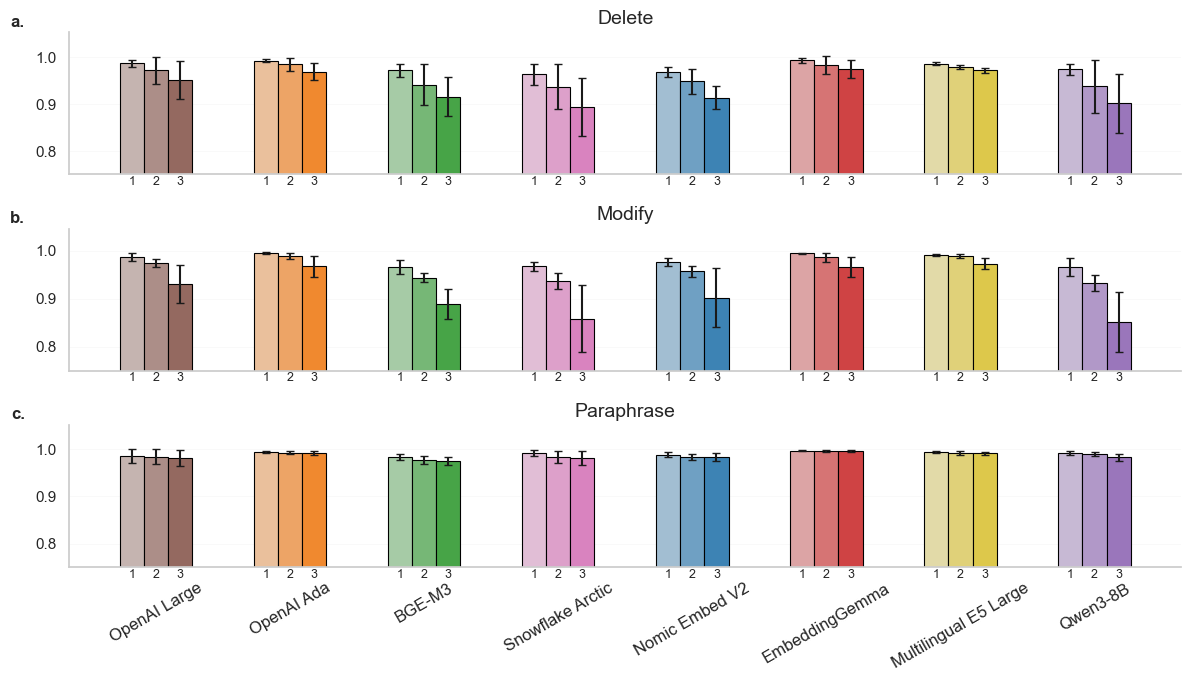


────────────────────────────────────────────────────────────
Metric: Cosine similarity  |  Language: swedish
        Delete  →  model: Snowflake Arctic           level: 3  mean: 0.8919  sd: 0.0642
        Modify  →  model: Snowflake Arctic           level: 3  mean: 0.8683  sd: 0.0844
    Paraphrase  →  model: Nomic Embed V2             level: 3  mean: 0.9679  sd: 0.0157
────────────────────────────────────────────────────────────

Cosine similarity  |  Language: swedish


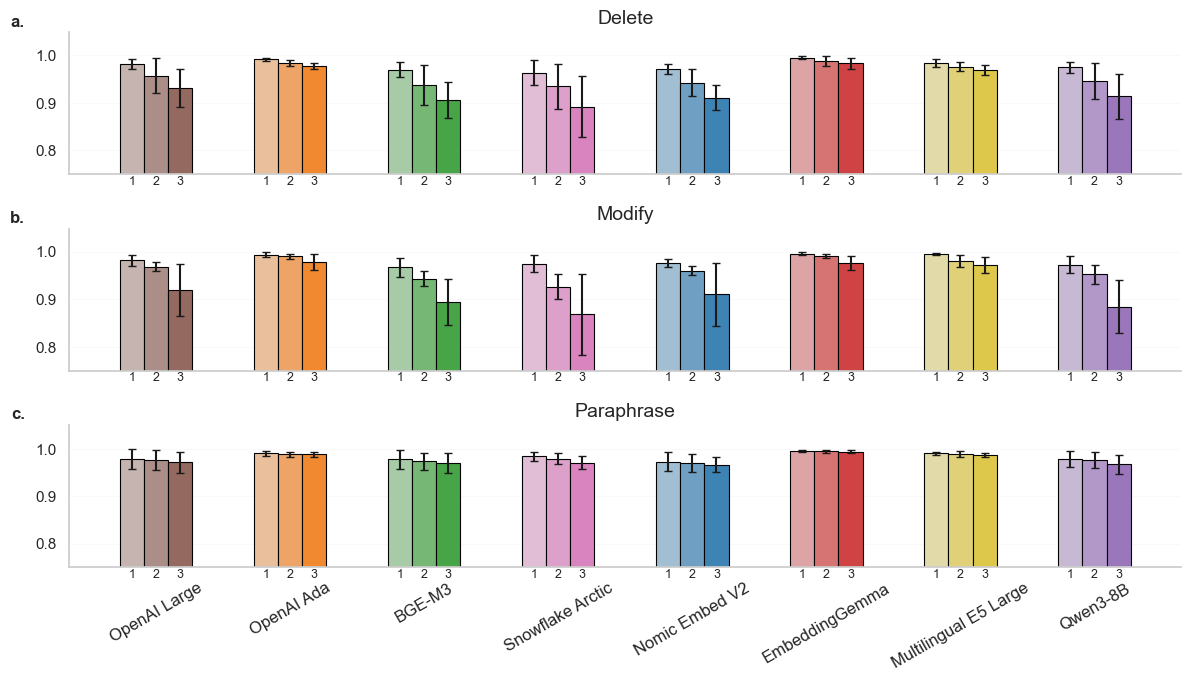


────────────────────────────────────────────────────────────
Metric: Cosine similarity  |  Language: finnish
        Delete  →  model: Qwen3-8B                   level: 3  mean: 0.8916  sd: 0.0571
        Modify  →  model: Qwen3-8B                   level: 3  mean: 0.8457  sd: 0.0765
    Paraphrase  →  model: BGE-M3                     level: 3  mean: 0.9659  sd: 0.0203
────────────────────────────────────────────────────────────

Cosine similarity  |  Language: finnish


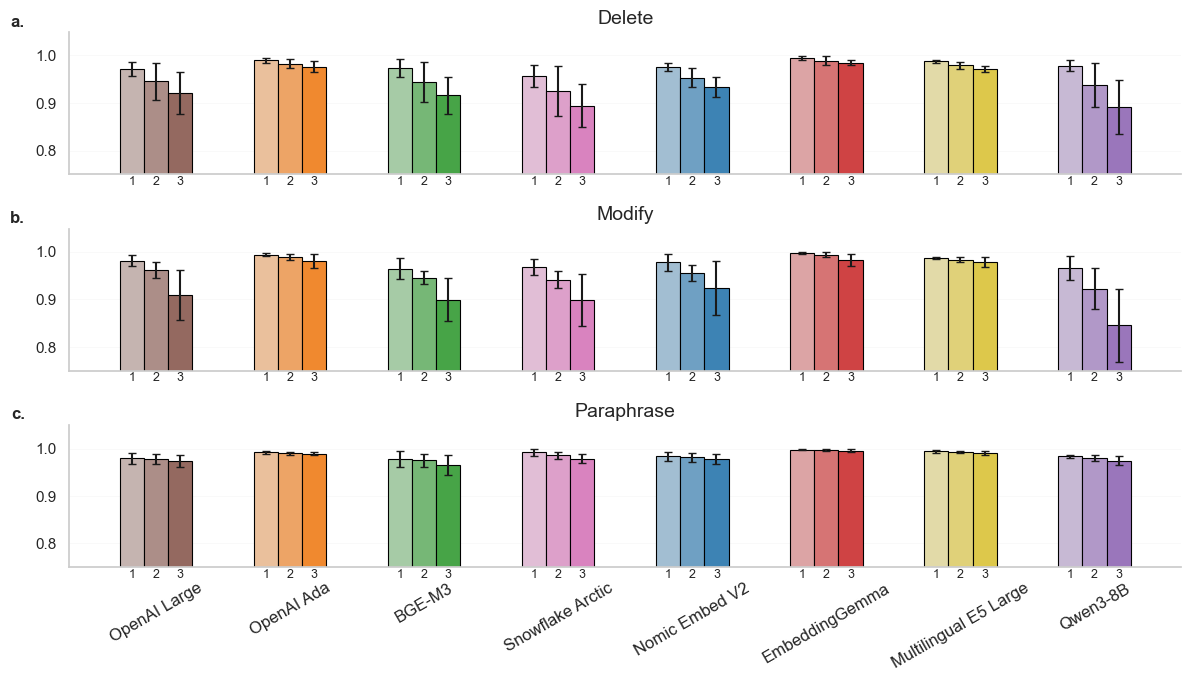


────────────────────────────────────────────────────────────
Metric: Euclidean distance  |  Language: english
        Delete  →  model: EmbeddingGemma             level: 1  mean: 0.1144  sd: 0.0344
        Modify  →  model: EmbeddingGemma             level: 1  mean: 0.1016  sd: 0.0106
    Paraphrase  →  model: EmbeddingGemma             level: 1  mean: 0.0679  sd: 0.0184
────────────────────────────────────────────────────────────

Euclidean distance  |  Language: english


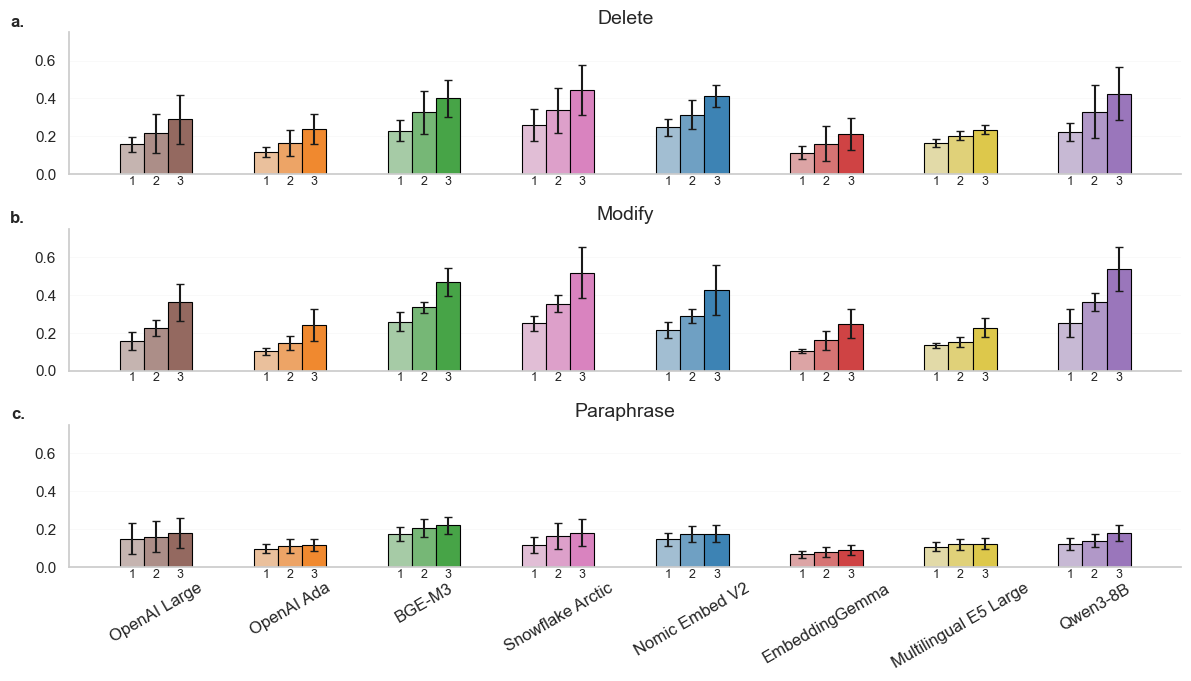


────────────────────────────────────────────────────────────
Metric: Euclidean distance  |  Language: swedish
        Delete  →  model: EmbeddingGemma             level: 1  mean: 0.0969  sd: 0.0358
        Modify  →  model: EmbeddingGemma             level: 1  mean: 0.0829  sd: 0.0313
    Paraphrase  →  model: EmbeddingGemma             level: 1  mean: 0.0806  sd: 0.0343
────────────────────────────────────────────────────────────

Euclidean distance  |  Language: swedish


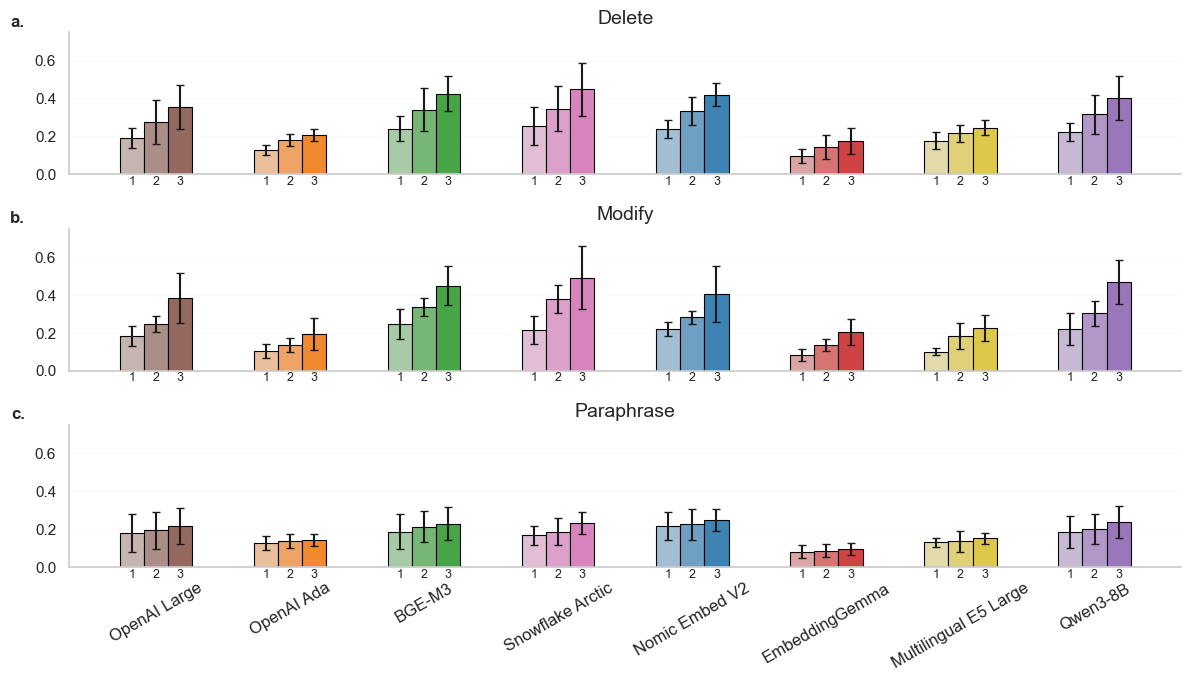


────────────────────────────────────────────────────────────
Metric: Euclidean distance  |  Language: finnish
        Delete  →  model: EmbeddingGemma             level: 1  mean: 0.0921  sd: 0.0351
        Modify  →  model: EmbeddingGemma             level: 1  mean: 0.0749  sd: 0.0227
    Paraphrase  →  model: EmbeddingGemma             level: 1  mean: 0.0610  sd: 0.0174
────────────────────────────────────────────────────────────

Euclidean distance  |  Language: finnish


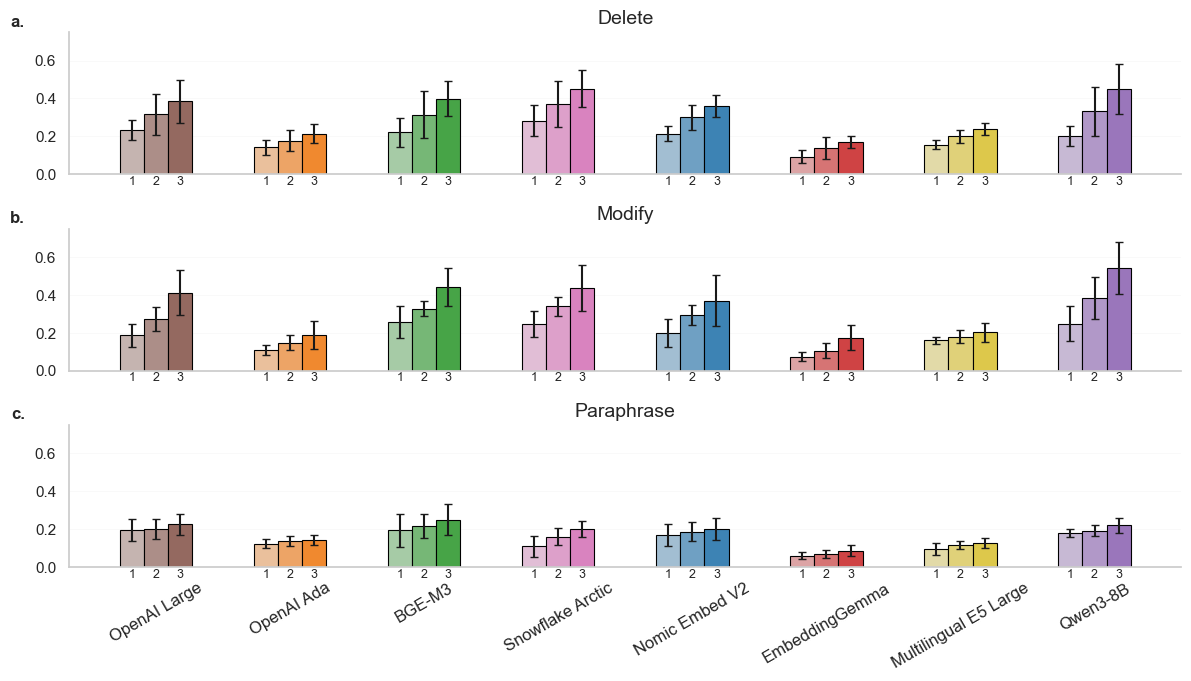


────────────────────────────────────────────────────────────
Metric: L1 distance  |  Language: english
        Delete  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.2413
        Modify  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.1856
    Paraphrase  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.1998
────────────────────────────────────────────────────────────

L1 distance  |  Language: english


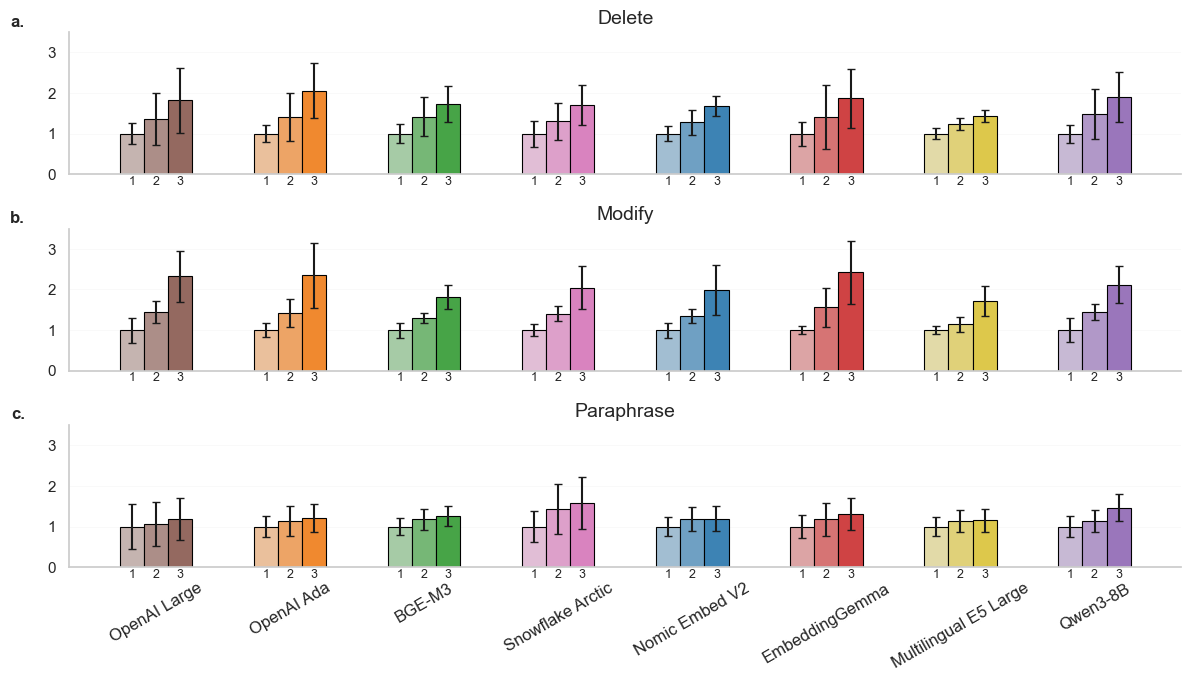


────────────────────────────────────────────────────────────
Metric: L1 distance  |  Language: swedish
        Delete  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.2741
        Modify  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.3203
    Paraphrase  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.4858
────────────────────────────────────────────────────────────

L1 distance  |  Language: swedish


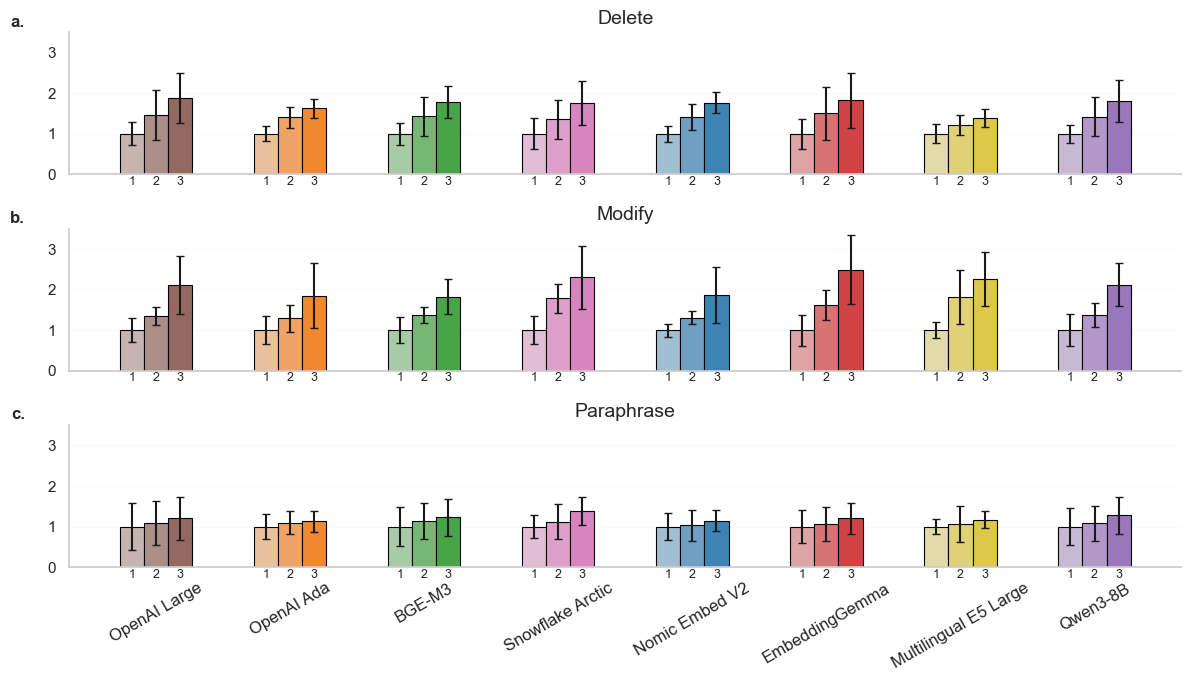


────────────────────────────────────────────────────────────
Metric: L1 distance  |  Language: finnish
        Delete  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.3460
        Modify  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.3202
    Paraphrase  →  model: BGE-M3                     level: 1  mean: 1.0000  sd: 0.4487
────────────────────────────────────────────────────────────

L1 distance  |  Language: finnish


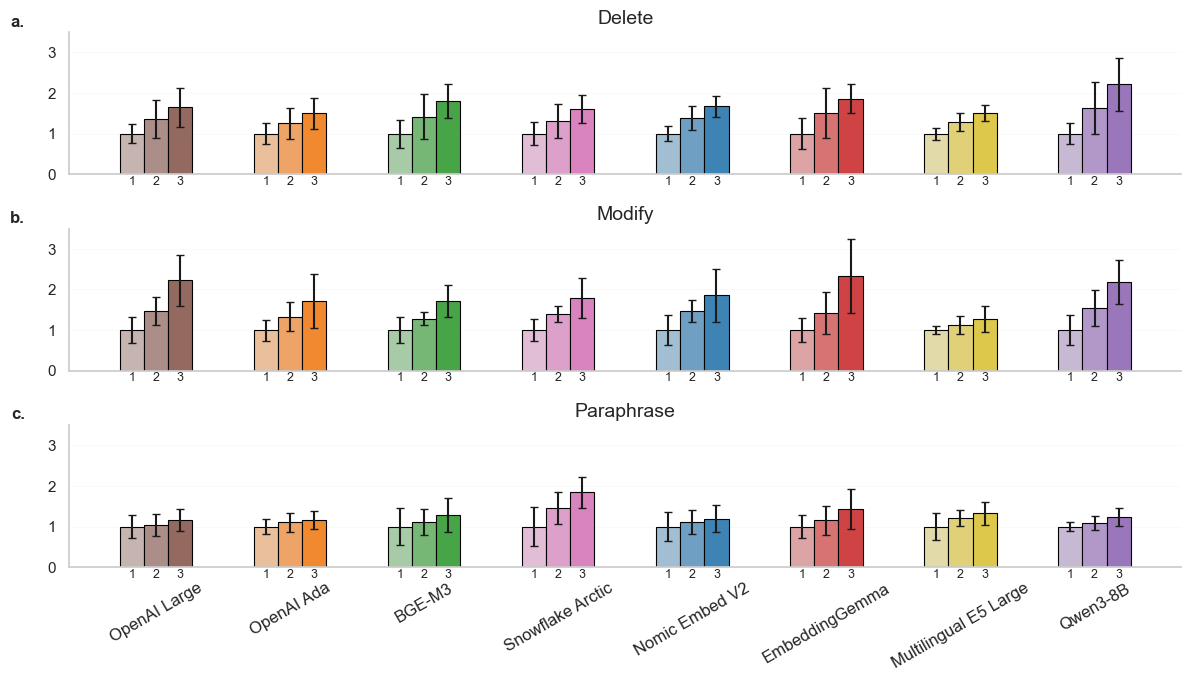

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

variation_types = ["delete", "mod", "synonyms"]
variation_title_map = {"delete": "Delete", "mod": "Modify", "synonyms": "Paraphrase"}

embedding_metrics = [
    "cosine_similarity",
    "euclidean_distance",
    "l1_distance",
]
metric_labels = {
    "cosine_similarity": "Cosine similarity",
    "euclidean_distance": "Euclidean distance",
    "l1_distance": "L1 distance",
}

languages = ["english", "swedish", "finnish"]

# Base colors for models
all_models = [m for m in df_all["model"].dropna().unique()]
base_model_colors = {
    "BGE-M3": "#2ca02c",
    "Snowflake Arctic": "#e377c2",
    "Nomic Embed V2": "#1f77b4",
    "Multilingual E5 Large": "#E8CD31",
    "Qwen3-8B": "#9467bd",
    "OpenAI Large": "#8c564b",
    "OpenAI Ada": "#ff7e0ee5",
    "EmbeddingGemma": "#d62728",
}


def shade(color, mix_with=(0.9, 0.9, 0.9), alpha=0.0):
    base = np.array(to_rgb(color))
    mix = np.array(mix_with)
    grey = np.array([0.7, 0.7, 0.7])
    base = 0.8 * base + 0.2 * grey
    return tuple((1 - alpha) * base + alpha * mix)


level_to_alpha = {1: 0.6, 2: 0.3, 3: 0.0}
levels = [1, 2, 3]

for metric in embedding_metrics:
    for lang in languages:
        lang_df = df_all[df_all["language"] == lang].copy()
        models = [m for m in all_models if m in lang_df["model"].unique()]
        if not models:
            continue

        fig, axes = plt.subplots(3, 1, figsize=(12, 2.8 * 3), sharex=True)

        # Aggregate stats: mean, std
        agg = (
            lang_df.groupby(["variation_type", "model", "variation_level"])[metric]
            .agg(["mean", "std"])
            .reset_index()
        )

        # L1 distance normalization (+ scale SD)
        if metric == "l1_distance":
            for vtype in variation_types:
                for m in models:
                    mask = (agg["variation_type"] == vtype) & (agg["model"] == m)
                    rows = agg[mask]
                    base_row = rows[rows["variation_level"] == 1]
                    if len(base_row) == 1:
                        base_val = float(base_row["mean"].iloc[0])
                        if base_val != 0:
                            agg.loc[mask, "mean"] /= base_val
                            agg.loc[mask, "std"] /= base_val

        # Min scores
        print(f"\n{'─' * 60}")
        print(f"Metric: {metric_labels[metric]}  |  Language: {lang}")
        for vtype in variation_types:
            subset = agg[agg["variation_type"] == vtype]
            if subset.empty:
                continue
            idx_min = subset["mean"].idxmin()
            row = subset.loc[idx_min]
            print(
                f"  {variation_title_map[vtype]:>12}  →  "
                f"model: {row['model']:<25}  "
                f"level: {int(row['variation_level'])}  "
                f"mean: {row['mean']:.4f}  "
                f"sd: {row['std']:.4f}"
            )
        print(f"{'─' * 60}\n")

        x = np.arange(len(models))
        bar_width = 0.18
        offsets = {1: -bar_width, 2: 0.0, 3: +bar_width}

        for row_idx, vtype in enumerate(variation_types):
            ax = axes[row_idx]
            a = agg[agg["variation_type"] == vtype]

            for lvl in levels:
                means, sderr, colors, x_positions = [], [], [], []

                for i, m in enumerate(models):
                    row = a[(a["model"] == m) & (a["variation_level"] == lvl)]
                    if len(row) == 1:
                        means.append(float(row["mean"].iloc[0]))
                        sd = (
                            float(row["std"].iloc[0])
                            if not np.isnan(row["std"].iloc[0])
                            else 0.0
                        )
                        sderr.append(sd)
                    else:
                        means.append(np.nan)
                        sderr.append(0.0)

                    base_c = base_model_colors[m]
                    colors.append(shade(base_c, (0.9, 0.9, 0.9), level_to_alpha[lvl]))
                    x_positions.append(x[i] + offsets[lvl])

                ax.bar(
                    x_positions,
                    means,
                    yerr=sderr,  # SD error bars
                    width=bar_width,
                    capsize=3,
                    linewidth=0.8,
                    edgecolor="black",
                    color=colors,
                )

            ax.set_title(f"{variation_title_map[vtype]}", fontsize=14)

            if metric == "euclidean_distance":
                ax.set_ylim(0, 0.75)
            elif metric == "l1_distance":
                ax.set_ylim(0, 3.5)
            else:
                ax.set_ylim(0.75)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(axis="y", linewidth=0.4, alpha=0.2)
            ax.grid(axis="x", visible=False)
            ax.set_axisbelow(True)

            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=30, ha="center", fontsize=12)

            for lvl in levels:
                for i in range(len(models)):
                    ax.text(
                        x[i] + offsets[lvl],
                        -0.01,
                        str(lvl),
                        transform=ax.get_xaxis_transform(),
                        ha="center",
                        va="top",
                        fontsize=9,
                    )

            panel_label = chr(97 + row_idx) + "."
            ax.text(
                -0.04,
                1.04,
                panel_label,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                ha="right",
            )

        print(f"{metric_labels[metric]}  |  Language: {lang}")
        plt.tight_layout(rect=[0, 0.12, 1, 0.95])

        fig.savefig(
            f"{BASE}/results/figures/{metric}_{lang}_by_model_groups_sd.svg",
            format="svg",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


Language: english


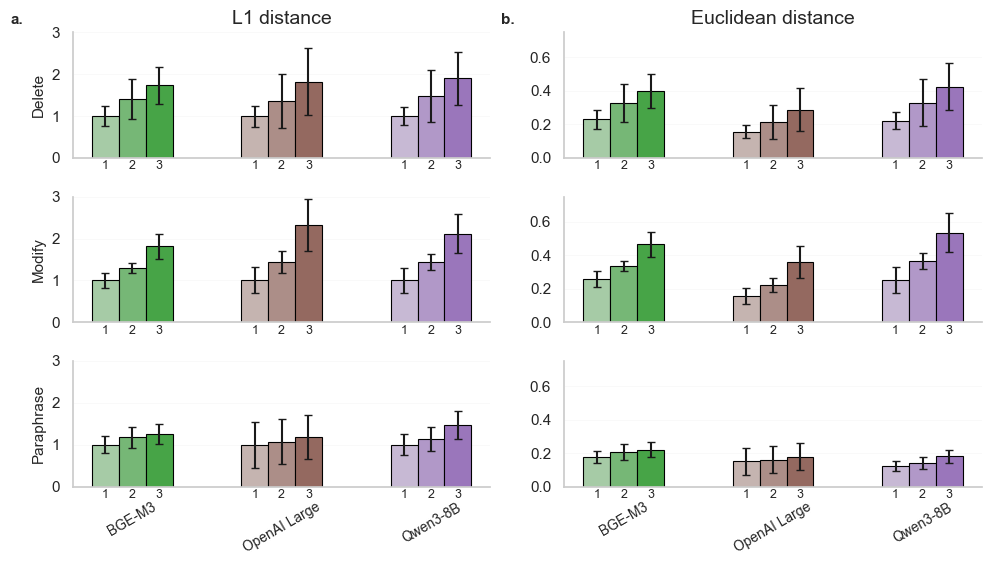

Language: swedish


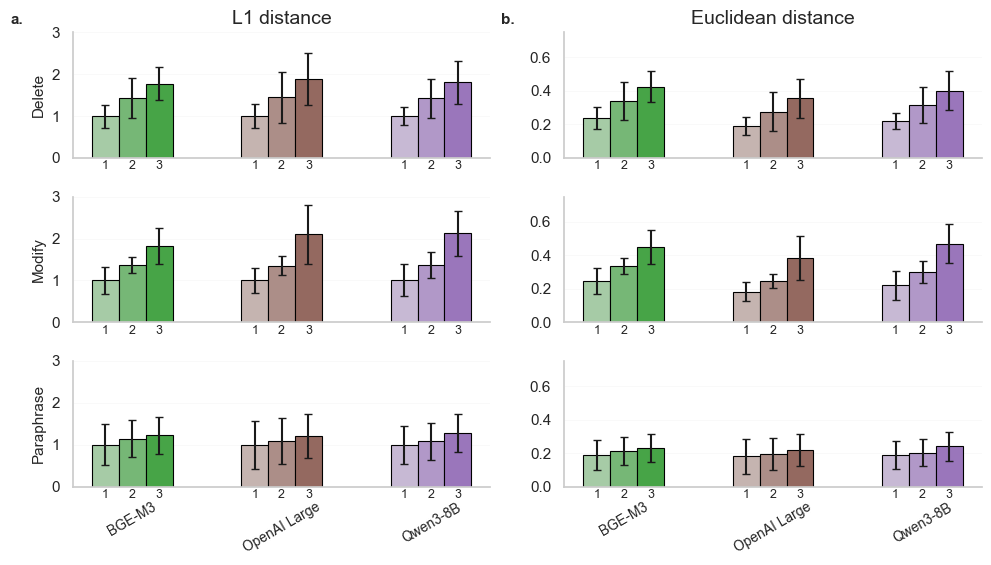

Language: finnish


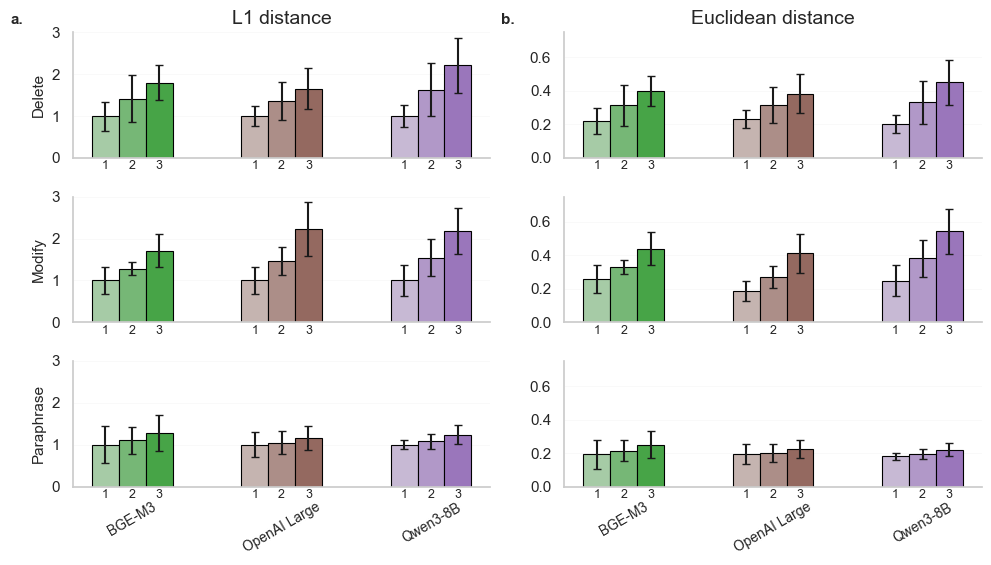

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

variation_types = ["delete", "mod", "synonyms"]
variation_title_map = {"delete": "Delete", "mod": "Modify", "synonyms": "Paraphrase"}

# L1 on the left, Euclidean on the right
embedding_metrics = ["l1_distance", "euclidean_distance"]
metric_labels = {
    "euclidean_distance": "Euclidean distance",
    "l1_distance": "L1 distance",
}

languages = ["english", "swedish", "finnish"]
selected_models = ["BGE-M3", "OpenAI Large", "Qwen3-8B"]


def shade(color, mix_with=(0.9, 0.9, 0.9), alpha=0.0):
    base = np.array(to_rgb(color))
    mix = np.array(mix_with)
    grey = np.array([0.7, 0.7, 0.7])
    base = 0.8 * base + 0.2 * grey
    return tuple((1 - alpha) * base + alpha * mix)


level_to_alpha = {1: 0.6, 2: 0.3, 3: 0.0}
levels = [1, 2, 3]

for lang in languages:
    lang_df = df_all[df_all["language"] == lang].copy()

    models = [m for m in selected_models if m in lang_df["model"].unique()]
    if not models:
        continue

    fig, axes = plt.subplots(
        len(variation_types),
        len(embedding_metrics),
        figsize=(10, 7),
        sharex=True,
        sharey="col",
    )

    x = np.arange(len(models))
    bar_width = 0.18
    offsets = {1: -bar_width, 2: 0.0, 3: +bar_width}

    metric_aggs = {}

    for metric in embedding_metrics:
        agg = (
            lang_df.groupby(["variation_type", "model", "variation_level"])[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        # SD bars 
        agg["sd"] = agg["std"]

        # L1 scaling: per (variation_type, model) divide all levels / level 1 mean and scale SD by the same factor
        if metric == "l1_distance":
            for vtype in variation_types:
                for m in models:
                    mask = (agg["variation_type"] == vtype) & (agg["model"] == m)
                    rows = agg[mask]
                    base_row = rows[rows["variation_level"] == 1]
                    if len(base_row) == 1:
                        base_val = float(base_row["mean"].iloc[0])
                        if base_val != 0:
                            agg.loc[mask, "mean"] = agg.loc[mask, "mean"] / base_val
                            agg.loc[mask, "sd"] = agg.loc[mask, "sd"] / base_val

        metric_aggs[metric] = agg

    level_handles = [
        Patch(
            facecolor=shade("#4c78a8", (0.9, 0.9, 0.9), level_to_alpha[lvl]),
            edgecolor="black",
            label=str(lvl),
        )
        for lvl in levels
    ]

    for col_idx, metric in enumerate(embedding_metrics):
        agg = metric_aggs[metric]

        for row_idx, vtype in enumerate(variation_types):
            ax = axes[row_idx, col_idx]
            subset = agg[agg["variation_type"] == vtype]

            for lvl in levels:
                means, yerrs, colors, x_positions = [], [], [], []

                for i, m in enumerate(models):
                    row = subset[
                        (subset["model"] == m) & (subset["variation_level"] == lvl)
                    ]
                    if len(row) == 1:
                        means.append(float(row["mean"].iloc[0]))
                        sd = (
                            float(row["sd"].iloc[0])
                            if not np.isnan(row["sd"].iloc[0])
                            else 0.0
                        )
                        yerrs.append(sd)
                    else:
                        means.append(np.nan)
                        yerrs.append(0.0)

                    base_c = base_model_colors[m]
                    colors.append(shade(base_c, (0.9, 0.9, 0.9), level_to_alpha[lvl]))
                    x_positions.append(x[i] + offsets[lvl])

                ax.bar(
                    x_positions,
                    means,
                    yerr=yerrs,  # SD
                    width=bar_width,
                    capsize=3,
                    linewidth=0.8,
                    edgecolor="black",
                    color=colors,
                )

            if row_idx == 0:
                ax.set_title(metric_labels[metric], fontsize=14)

            if col_idx == 0:
                ax.set_ylabel(f"{variation_title_map[vtype]}", fontsize=11)
            else:
                ax.set_ylabel("")

            if metric == "euclidean_distance":
                ax.set_ylim(0, 0.75)
            elif metric == "l1_distance":
                ax.set_ylim(0, 3)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(axis="y", linestyle="-", linewidth=0.4, alpha=0.2)
            ax.grid(axis="x", visible=False)
            ax.set_axisbelow(True)

            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=30, ha="center", fontsize=10)

            for lvl in levels:
                for i in range(len(models)):
                    ax.text(
                        x[i] + offsets[lvl],
                        -0.02,
                        str(lvl),
                        transform=ax.get_xaxis_transform(),
                        ha="center",
                        va="top",
                        fontsize=9,
                    )

            col_labels = ["a.", "b."]  # a = left (L1), b = right (Euclidean)
            if row_idx == 0:
                ax.text(
                    -0.12,
                    1.04,
                    col_labels[col_idx],
                    transform=ax.transAxes,
                    fontsize=11,
                    fontweight="bold",
                    va="bottom",
                    ha="right",
                )

    print(f"Language: {lang}")
    plt.tight_layout(rect=[0, 0.12, 1, 0.95])

    fig.savefig(
        f"{BASE}/results/figures/l1_euclid_{lang}_three_models_sd.svg",
        format="svg",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 4. Correlations (Pearsons P)

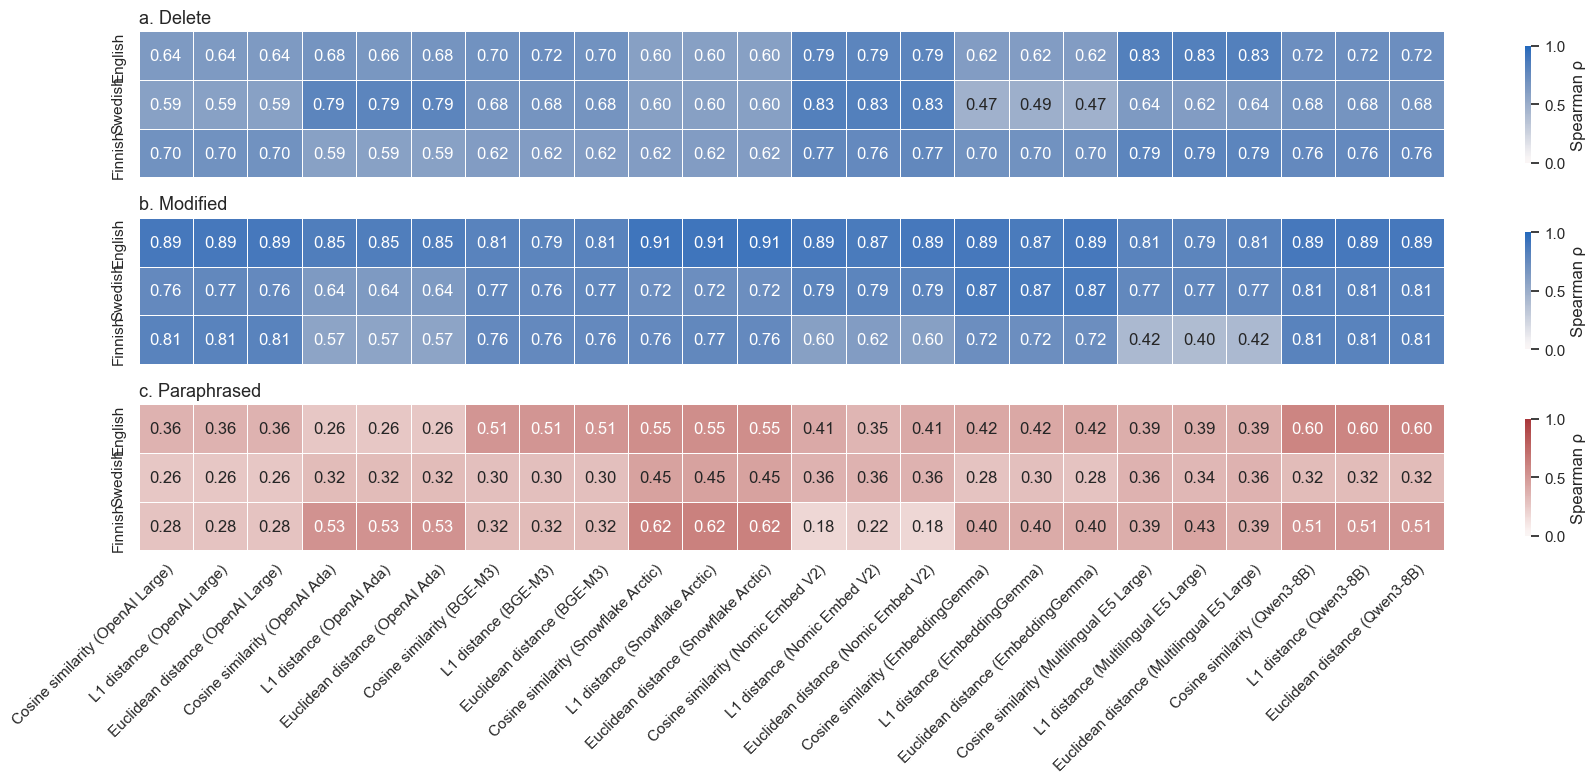

In [10]:
import re
from scipy.stats import spearmanr

# Config
positive_metrics = ["euclidean_distance", "l1_distance"]  # larger = worse, for these metrics
ordered_metrics = [
    "cosine_similarity",
    "l1_distance",
    "euclidean_distance",
]
metric_display = {
    "cosine_similarity": "Cosine similarity",
    "l1_distance": "L1 distance",
    "euclidean_distance": "Euclidean distance",
}
variation_order = ["Delete", "Modified", "Paraphrased"]
titles = ["a. Delete", "b. Modified", "c. Paraphrased"]
language_order = ["English", "Swedish", "Finnish"]

# Normalize 
vtype_map = {
    "delete": "Delete",
    "deletion": "Delete",
    "mod": "Modified",
    "modify": "Modified",
    "modified": "Modified",
    "paraphrase": "Paraphrased",
    "paraphrased": "Paraphrased",
    "synonym": "Paraphrased",
    "synonyms": "Paraphrased",
}
df_all = df_all.copy()
df_all["variation_group"] = (
    df_all["variation_type"].astype(str).str.strip().str.lower().map(vtype_map)
)

# Model list in display order
models = df_all["model"].dropna().unique().tolist()


def col_label(metric_key: str, model_name: str) -> str:
    return f"{metric_display[metric_key]} ({model_name})"



# One big figure (3 stacked heatmaps)
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

for i, group in enumerate(variation_order):
    # Prepare
    all_columns = [col_label(mk, mdl) for mdl in models for mk in ordered_metrics]
    plot_df = pd.DataFrame(index=language_order, columns=all_columns, dtype=float)

    # Spearman rho per language x [metric(model)]
    for mdl in models:
        df_m = df_all[(df_all["model"] == mdl) & (df_all["variation_group"] == group)]
        if df_m.empty:
            continue

        for lang in df_m["language"].dropna().unique():
            lang_disp = str(lang).title()
            for mk in ordered_metrics:
                data = df_m[df_m["language"] == lang][[mk, "variation_level"]].dropna()
                if (
                    data.empty
                    or data[mk].nunique() <= 1
                    or data["variation_level"].nunique() <= 1
                ):
                    val = None
                else:
                    rho, _ = spearmanr(data["variation_level"], data[mk])
                    if (
                        mk not in positive_metrics
                    ):  # Flip sign similarities and dot product
                        rho *= -1
                    val = round(float(rho), 2)
                plot_df.loc[lang_disp, col_label(mk, mdl)] = val

    existing_cols = [c for c in all_columns if c in plot_df.columns]
    plot_df = plot_df[existing_cols]

    sns.heatmap(
        plot_df.astype(float),
        annot=True,
        cmap="vlag_r" if group in ["Delete", "Modified"] else "vlag",
        center=0,
        vmin=0,
        vmax=1,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
        ax=axes[i],
    )
    axes[i].set_title(titles[i], loc="left", fontsize=13)

    if i < len(axes) - 1:
        axes[i].set_xticklabels([])
    else:
        axes[i].set_xticklabels(
            axes[i].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
        )
        axes[i].tick_params(axis="x", which="major", pad=2)

plt.tight_layout()
outpath = f"{BASE}/results/figures/Spearman_all_models.svg"
plt.savefig(outpath, format="svg", dpi=300, bbox_inches="tight")
plt.show()
